In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from torchvision import transforms
from tensorflow.keras import layers, Sequential
import time
from IPython import display
import random
from scipy.linalg import sqrtm
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing import image
import keras_tuner as kt

In [ ]:
!pip install datasets
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 20.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 10.7 MB/s eta 0:00:00


In [ ]:
# loading celeb_a dataset
dataset = load_dataset("eurecom-ds/celeba")

train_data = dataset["train"]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/4.04k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

train-00000-of-00018.parquet:   0%|          | 0.00/480M [00:00<?, ?B/s]

...

test-00000-of-00001.parquet:   0%|          | 0.00/138M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/162770 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/19867 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/19962 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

In [ ]:
# display readable attribute names
attribute_names = [
    "5_o_Clock_Shadow", "Arched_Eyebrows", "Attractive", "Bags_Under_Eyes", "Bald",
    "Bangs", "Big_Lips", "Big_Nose", "Black_Hair", "Blond_Hair", "Blurry", "Brown_Hair",
    "Bushy_Eyebrows", "Chubby", "Double_Chin", "Eyeglasses", "Goatee", "Gray_Hair",
    "Heavy_Makeup", "High_Cheekbones", "Male", "Mouth_Slightly_Open", "Mustache",
    "Narrow_Eyes", "No_Beard", "Oval_Face", "Pale_Skin", "Pointy_Nose", "Receding_Hairline",
    "Rosy_Cheeks", "Sideburns", "Smiling", "Straight_Hair", "Wavy_Hair", "Wearing_Earrings",
    "Wearing_Hat", "Wearing_Lipstick", "Wearing_Necklace", "Wearing_Necktie", "Young"
]

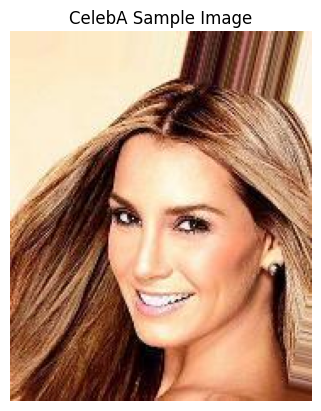

Image size: (178, 218)
Attributes (binary): [0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1]
Text attributes:
5_o_Clock_Shadow: No
Arched_Eyebrows: Yes
Attractive: Yes
Bags_Under_Eyes: No
Bald: No
Bangs: No
Big_Lips: No
Big_Nose: No
Black_Hair: No
Blond_Hair: No
Blurry: No
Brown_Hair: Yes
Bushy_Eyebrows: No
Chubby: No
Double_Chin: No
Eyeglasses: No
Goatee: No
Gray_Hair: No
Heavy_Makeup: Yes
High_Cheekbones: Yes
Male: No
Mouth_Slightly_Open: Yes
Mustache: No
Narrow_Eyes: No
No_Beard: Yes
Oval_Face: No
Pale_Skin: No
Pointy_Nose: Yes
Receding_Hairline: No
Rosy_Cheeks: No
Sideburns: No
Smiling: Yes
Straight_Hair: Yes
Wavy_Hair: No
Wearing_Earrings: Yes
Wearing_Hat: No
Wearing_Lipstick: Yes
Wearing_Necklace: No
Wearing_Necktie: No
Young: Yes


In [ ]:
# Check an example of the features
example = dataset["train"][0]
# Display the image
plt.imshow(example["image"])
plt.axis("off")  # Remove axis
plt.title("CelebA Sample Image")
plt.show()

print("Image size:", example["image"].size)
# View the attributes as binary values
print("Attributes (binary):", example["attributes"])

print("Text attributes:")
for name, value in zip(attribute_names, example["attributes"]):
    print(f"{name}: {'Yes' if value else 'No'}")

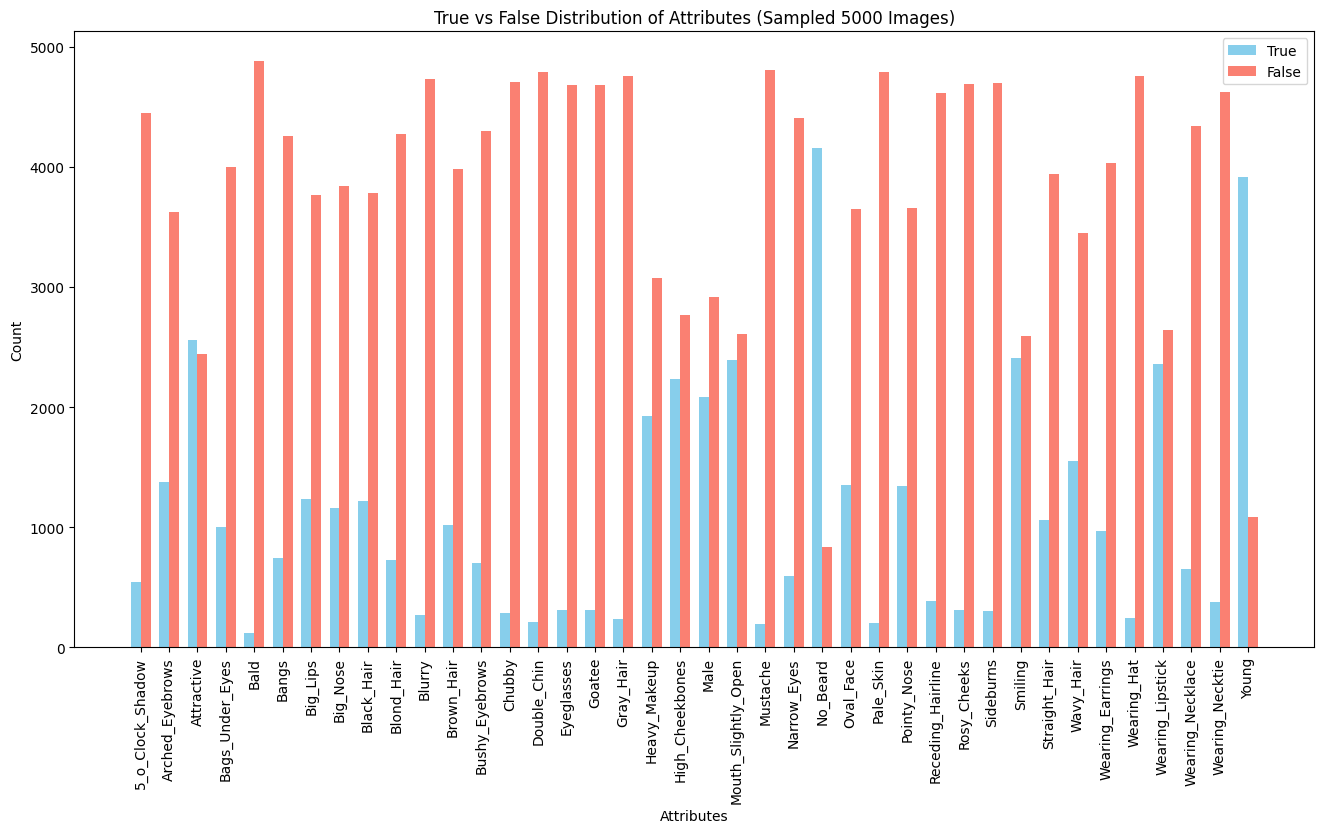

In [ ]:
# Inspect Attribute Balance
subset_dataset = dataset['train']
def inspect_attribute_balance_corrected(dataset, num_samples=5000):
    """
    Inspect the balance of attributes (True/False counts) in the dataset.
    """
    true_counts = np.zeros(40)  # There are 40 attributes
    false_counts = np.zeros(40)

    processed_samples = 0  # Track the number of processed samples

    for sample in dataset:  # Iterate over the dataset split
        if processed_samples >= num_samples:
            break

        attributes = np.array(sample['attributes'])  # Access the 'attributes' field

        # Update True/False counts
        true_counts += (attributes == 1)
        false_counts += (attributes == 0)

        processed_samples += 1

    return true_counts, false_counts

true_counts, false_counts = inspect_attribute_balance_corrected(subset_dataset, num_samples=5000)

plt.figure(figsize=(16, 8))
x = np.arange(len(attribute_names))  # X-axis positions
width = 0.35  # Bar width

plt.bar(x - width / 2, true_counts, width, label="True", color='skyblue')
plt.bar(x + width / 2, false_counts, width, label="False", color='salmon')
plt.xticks(x, attribute_names, rotation=90)
plt.title(f"True vs False Distribution of Attributes (Sampled 5000 Images)")
plt.xlabel("Attributes")
plt.ylabel("Count")
plt.legend()
plt.show()

**Comment**: a number of attributes are underrepresented in the dataset, where the model may not be able to learn effectively.  However, many attributes are gender or age implied (makeups, mustaches, bags_under_eyes, etc.), therefore the focus is to balance some common attributes like 'male', 'young', and 'smiling'

In [ ]:
def balance_dataset(dataset, relevant_indices, samples_per_group=None):
    attributes = dataset["train"]["attributes"]
    attributes_df = pd.DataFrame(attributes, columns=[f"attr_{i}" for i in range(len(attributes[0]))])
    # Select relevant attributes (Male, Young, Smiling)
    relevant_attributes = attributes_df.iloc[:, relevant_indices]
    relevant_attributes.columns = ["Male", "Young", "Smiling"]
    relevant_attributes["index"] = relevant_attributes.index  # Add index for tracking
    grouped = relevant_attributes.groupby(["Male", "Young", "Smiling"])
    if samples_per_group is None:
        samples_per_group = min(len(group) for _, group in grouped)
    print(f"Balancing with {samples_per_group} samples per group.")
    # Collect sampled indices
    sampled_indices = []
    for combination, group in grouped:
        if len(group) >= samples_per_group:
            sampled_indices.extend(group.sample(samples_per_group)["index"])
        else:
            print(f"Skipping group {combination} (only {len(group)} samples available).")
    if not sampled_indices:
        print("No samples were selected. Dataset balancing failed.")
        return None
    return dataset["train"].select(sampled_indices)

# Define relevant indices
relevant_indices = [
    attribute_names.index("Male"),
    attribute_names.index("Young"),
    attribute_names.index("Smiling")
]

# Balance the dataset
balanced_dataset = balance_dataset(dataset, relevant_indices, samples_per_group=3000)

if balanced_dataset is None:
    print("Dataset balancing failed. Try reducing `samples_per_group`.")
else:
    print(f"Balanced dataset created with {len(balanced_dataset)} samples.")
    # Convert to TensorFlow format
    BATCH_SIZE = 64
    balanced_tf_dataset = balanced_dataset.to_tf_dataset(
        columns=["image", "attributes"],
        shuffle=True,
        batch_size=BATCH_SIZE
    )

<ipython-input-7-d1313aefda51>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevant_attributes["index"] = relevant_attributes.index  # Add index for tracking


Balancing with 3000 samples per group.
Balanced dataset created with 24000 samples.


In [ ]:
# Preprocess images
def preprocess(data):
    img = data["image"]
    img = tf.image.resize(img, (128, 128))  # Resize
    img = tf.cast(img, tf.float32) / 127.5 - 1.0  # Normalize to [-1, 1]
    attr = data["attributes"]
    return img, attr

# Apply preprocessing to the TensorFlow dataset
train_dataset = balanced_tf_dataset.map(preprocess).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
# Example to inspect a single batch
for image_batch, attribute_batch in train_dataset.take(1):
    print("Image batch shape:", image_batch.shape)
    print("Attribute batch shape:", attribute_batch.shape)

Image batch shape: (64, 128, 128, 3)
Attribute batch shape: (64, 40)


In [ ]:
train_images = []
for batch in train_dataset:
    images = batch.numpy()
    train_images.append(images)

train_images = np.concatenate(train_images, axis=0)

## Base Model

In [ ]:
def build_generator(noise_dim=100):
    model = Sequential([
        layers.Dense(8 * 8 * 256, use_bias=False, input_shape=(noise_dim,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((8, 8, 256)),  # Reshape to 8x8x256
        layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(3, (5, 5), strides=(4, 4), padding='same', activation='tanh')
    ])
    return model

generator = build_generator()

def build_discriminator():
    model = Sequential([
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=(128, 128, 3)),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)  # Output: probability (real or fake)
    ])
    return model

discriminator = build_discriminator()

# Optimizers
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
BATCH_SIZE = 64
LATENT_DIM = 100  # Noise vector size
EPOCHS = 50
SEED = tf.random.normal([16, LATENT_DIM])

# Loss functions
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

# Training step
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

# Training loop
def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        for image_batch in dataset:  # Only get the image batch, no attributes
            gen_loss, disc_loss = train_step(image_batch)

        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, SEED)
        print(f"Time for epoch {epoch + 1} is {time.time() - start:.2f} sec")

# Generate and save images
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        # Ensure that the image tensor is properly denormalized and converted to the correct dtype
        img = (predictions[i].numpy() + 1) / 2  # Denormalize to [0, 1] for RGB
        plt.imshow(img.astype(np.float32))  # Ensure the image is of dtype float32
        plt.axis("off")
    plt.savefig(f"image_at_epoch_{epoch:04d}.png")
    plt.show()


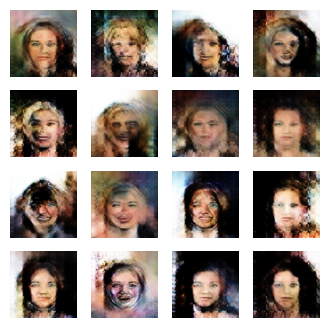

Time for epoch 50 is 48.01 sec


In [ ]:
train(train_dataset, EPOCHS)

# Save the  model
generator.save('generator_model_base.h5')
discriminator.save('discriminator_model_base.h5')

## Model Evaluation

In [ ]:
# Load the InceptionV3 model
inception_model = InceptionV3(include_top=False, weights='imagenet', pooling='avg')

# Preprocess function for InceptionV3 input
def preprocess_images(images):
    images = tf.image.resize(images, (299, 299))  # Resize to 299x299 for InceptionV3
    images = tf.keras.applications.inception_v3.preprocess_input(images)  # Preprocess for InceptionV3
    return images

# Function to calculate Inception Score (IS) with standard deviation
def calculate_is(generated_images):
    processed_images = preprocess_images(generated_images)  # Resize and preprocess images for InceptionV3
    features = inception_model(processed_images)
    softmax_probs = tf.nn.softmax(features)
    # Calculate IS: Compute the KL divergence and its mean
    mean_kl = tf.reduce_mean(tf.reduce_sum(softmax_probs * (tf.math.log(softmax_probs) - tf.math.log(tf.reduce_mean(softmax_probs, axis=0, keepdims=True))), axis=1))
    # Inception score (mean of KL divergence)
    inception_score = tf.exp(mean_kl)
    # Calculate standard deviation of IS
    kl_divergence_per_image = tf.reduce_sum(softmax_probs * (tf.math.log(softmax_probs) - tf.math.log(tf.reduce_mean(softmax_probs, axis=0, keepdims=True))), axis=1)
    stdev_kl = tf.math.reduce_std(kl_divergence_per_image)
    # Calculate IS mean and standard deviation
    is_mean = tf.exp(tf.reduce_mean(kl_divergence_per_image))
    is_stdev = tf.exp(stdev_kl)

    return is_mean.numpy(), is_stdev.numpy()

# Function to calculate FID
def calculate_fid(real_images, generated_images):
    # Compute the activations of the real and generated images using InceptionV3
    real_features = inception_model.predict(real_images)
    generated_features = inception_model.predict(generated_images)
    # Calculate the mean and covariance for both sets of features
    mu_real = np.mean(real_features, axis=0)
    sigma_real = np.cov(real_features, rowvar=False)
    mu_generated = np.mean(generated_features, axis=0)
    sigma_generated = np.cov(generated_features, rowvar=False)
    # Regularize covariance matrices to avoid singularity
    epsilon = 1e-6
    sigma_real += epsilon * np.eye(sigma_real.shape[0])
    sigma_generated += epsilon * np.eye(sigma_generated.shape[0])
    # Calculate the covariance mean
    covmean = sqrtm(sigma_real.dot(sigma_generated))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    # Calculate FID score
    fid_score = np.sum((mu_real - mu_generated) ** 2) + np.trace(sigma_real + sigma_generated - 2 * covmean)

    return fid_score

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
def get_random_real_images(dataset, num_samples):
    real_images = []

    for image_batch in dataset.take(num_samples):
        images = image_batch[0]
        real_images.append(images.numpy())  # Convert to numpy array

    real_images = np.concatenate(real_images, axis=0)
    return real_images

real_images = get_random_real_images(train_dataset, num_samples=100)

In [ ]:
# Calculate IS (mean and std)
is_mean, is_stdev = calculate_is(generated_images)
print(f"Inception Score Mean: {is_mean}, Standard Deviation: {is_stdev}")

# Calculate FID
fid_score = calculate_fid(real_images, generated_images)
print(f"FID Score: {fid_score}")

Inception Score Mean: 0.9999998807907104, Standard Deviation: 1.0
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step 
FID Score: 2904.3700366749986


## Hyperparameter Tuning

In [ ]:
class GAN(tf.keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super(GAN, self).__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super(GAN, self).compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    def train_step(self, data):
        real_images = data
        batch_size = tf.shape(real_images)[0]
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        # Generate fake images
        generated_images = self.generator(random_latent_vectors, training=True)
        # Combine real and fake images
        combined_images = tf.concat([real_images, generated_images], axis=0)
        labels = tf.concat([tf.ones((batch_size, 1)), tf.zeros((batch_size, 1))], axis=0)
        # Training the discriminator
        with tf.GradientTape() as disc_tape:
            predictions = self.discriminator(combined_images, training=True)
            d_loss = self.loss_fn(labels, predictions)
        grads = disc_tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_variables))

        # Misleading labels for generator
        misleading_labels = tf.ones((batch_size, 1))
        # Training the generator
        with tf.GradientTape() as gen_tape:
            predictions = self.discriminator(self.generator(random_latent_vectors, training=True), training=True)
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = gen_tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_variables))

        return {"d_loss": d_loss, "g_loss": g_loss}

In [ ]:
# Tuning filters and dropout rates
class HyperGAN_filters(kt.HyperModel):
    def make_discriminator_model(self, hp):
        model = tf.keras.Sequential()
        model.add(layers.Conv2D(hp.Choice("disc_filters_1", values=[64, 128, 256]),
                (5, 5),strides=(2, 2), padding="same", input_shape=[128, 128, 3], ))
        model.add(layers.LeakyReLU())
        model.add(layers.Dropout(hp.Choice("dropout_1", values=[0.0, 0.1, 0.2, 0.3])))
        model.add(layers.Conv2D(hp.Choice("disc_filters_2", values=[128, 256, 512]),
                (5, 5), strides=(2, 2), padding="same",))
        model.add(layers.LeakyReLU())
        model.add(layers.Dropout(hp.Choice("dropout_2", values=[0.0, 0.1, 0.2, 0.3])))
        model.add(layers.Flatten())
        model.add(layers.Dense(1))
        return model

    def make_generator_model(self, hp):
        model = tf.keras.Sequential()
        model.add(layers.Dense(8 * 8 * hp.Choice("gen_filters_1", values=[128, 256, 512]),
                use_bias=False, input_shape=(100,),  ))
        model.add(layers.BatchNormalization())
        model.add(layers.LeakyReLU())
        model.add(layers.Reshape((8, 8, hp.Choice("gen_filters_1", values=[128, 256, 512]))))
        model.add(layers.Conv2DTranspose(hp.Choice("gen_filters_2", values=[64, 128, 256]),
                (5, 5), strides=(2, 2), padding="same", use_bias=False,))
        model.add(layers.BatchNormalization())
        model.add(layers.LeakyReLU())
        model.add(layers.Conv2DTranspose(hp.Choice("gen_filters_3", values=[32, 64, 128]),
                (5, 5), strides=(2, 2), padding="same", use_bias=False,))
        model.add(layers.BatchNormalization())
        model.add(layers.LeakyReLU())
        model.add(layers.Conv2DTranspose(3, (5, 5), strides=(4, 4), padding="same", activation="tanh"))
        return model

    def build(self, hp):
        discriminator = self.make_discriminator_model(hp)
        generator = self.make_generator_model(hp)
        gan = GAN(discriminator, generator, latent_dim=100)
        gan.compile(
            d_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            g_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        )
        return gan

    def fit(self, hp, model, x, **kwargs):
        history = model.fit(x, **kwargs)
        d_loss = history.history["d_loss"][-1]
        if isinstance(d_loss, tf.Tensor):
            d_loss = float(d_loss.numpy())
        return d_loss


tuner = kt.BayesianOptimization(
    hypermodel=HyperGAN_filters(),
    objective=kt.Objective("d_loss", direction="min"),
    max_trials=30,
    directory="tuning_filters_1",
    project_name="hyper_gan",
)

tuner.search(train_images, epochs=10, batch_size=32)

best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

print("Best Trial:")
print(f"Hyperparameters: {best_trial.hyperparameters.values}")
print(f"Best d_loss: {best_trial.score}")

Trial 30 Complete [00h 01m 57s]
d_loss: 0.06528564542531967

Best d_loss So Far: 0.015125834383070469
Total elapsed time: 00h 55m 58s
Best Trial:
Hyperparameters: {'disc_filters_1': 128, 'dropout_1': 0.2, 'disc_filters_2': 512, 'dropout_2': 0.1, 'gen_filters_1': 128, 'gen_filters_2': 128, 'gen_filters_3': 32}
Best d_loss: 0.015125834383070469


**Comment**: Since the filter number cap is reached in the second convoltion layer of  discriminator, additional layer is added to discriminator for futher tuning

In [ ]:
# Tuning with additional layer
class HyperGAN_additional_layer(kt.HyperModel):
    def make_discriminator_model(self, hp):
        model = tf.keras.Sequential()
        model.add(layers.Conv2D(hp.Choice("disc_filters_1", values=[64, 128, 256]),
                (5, 5),strides=(2, 2), padding="same", input_shape=[128, 128, 3], ))
        model.add(layers.LeakyReLU())
        model.add(layers.Dropout(hp.Choice("dropout_1", values=[0.0, 0.1, 0.2, 0.3])))
        model.add(layers.Conv2D(hp.Choice("disc_filters_2", values=[128, 256, 512]),
                (5, 5), strides=(2, 2), padding="same",))
        model.add(layers.LeakyReLU())
        model.add(layers.Dropout(hp.Choice("dropout_2", values=[0.0, 0.1, 0.2, 0.3])))
        #additional layer
        model.add(layers.Conv2D(hp.Choice("disc_filters_3", values=[128, 256, 512]),
                (5, 5), strides=(2, 2), padding="same",))
        model.add(layers.LeakyReLU())
        model.add(layers.Dropout(hp.Choice("dropout_3", values=[0.0, 0.1, 0.2, 0.3])))
        model.add(layers.Flatten())
        model.add(layers.Dense(1))
        return model

    def make_generator_model(self, hp):
        model = tf.keras.Sequential()
        model.add(layers.Dense(8 * 8 * hp.Choice("gen_filters_1", values=[128, 256, 512]),
                use_bias=False, input_shape=(100,),  ))
        model.add(layers.BatchNormalization())
        model.add(layers.LeakyReLU())
        model.add(layers.Reshape((8, 8, hp.Choice("gen_filters_1", values=[128, 256, 512]))))
        model.add(layers.Conv2DTranspose(hp.Choice("gen_filters_2", values=[64, 128, 256]),
                (5, 5), strides=(2, 2), padding="same", use_bias=False,))
        model.add(layers.BatchNormalization())
        model.add(layers.LeakyReLU())
        model.add(layers.Conv2DTranspose(hp.Choice("gen_filters_3", values=[32, 64, 128]),
                (5, 5), strides=(2, 2), padding="same", use_bias=False,))
        model.add(layers.BatchNormalization())
        model.add(layers.LeakyReLU())
        model.add(layers.Conv2DTranspose(3, (5, 5), strides=(4, 4), padding="same", activation="tanh"))
        return model

    def build(self, hp):
        discriminator = self.make_discriminator_model(hp)
        generator = self.make_generator_model(hp)
        gan = GAN(discriminator, generator, latent_dim=100)
        gan.compile(
            d_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            g_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        )
        return gan

    def fit(self, hp, model, x, **kwargs):
        history = model.fit(x, **kwargs)
        d_loss = history.history["d_loss"][-1]
        if isinstance(d_loss, tf.Tensor):
            d_loss = float(d_loss.numpy())
        return d_loss

tuner = kt.BayesianOptimization(
    hypermodel=HyperGAN_additional_layer(),
    objective=kt.Objective("d_loss", direction="min"),
    max_trials=30,
    directory="filter_tuning2",
    project_name="hyper_gan",
)

tuner.search(train_images, epochs=10, batch_size=32)

best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

print("Best Trial:")
print(f"Hyperparameters: {best_trial.hyperparameters.values}")
print(f"Best d_loss: {best_trial.score}")

Trial 30 Complete [00h 02m 38s]
d_loss: 0.02085280790925026

Best d_loss So Far: 0.001619580201804638
Total elapsed time: 01h 16m 05s
Best Trial:
Hyperparameters: {'disc_filters_1': 256, 'dropout_1': 0.0, 'disc_filters_2': 512, 'dropout_2': 0.2, 'disc_filters_3': 512, 'dropout_3': 0.2, 'gen_filters_1': 128, 'gen_filters_2': 256, 'gen_filters_3': 32}
Best d_loss: 0.001619580201804638


**Comment**: Since now multiple layers are reaching the filter number cap,  additonal Conv2DTranspose and Conv2D are added to the generator and discriminator respectively.

In [ ]:
# Tuning with additional layers
class HyperGAN_additional_layer2(kt.HyperModel):
    def make_discriminator_model(self, hp):
        model = tf.keras.Sequential()
        model.add(layers.Conv2D(hp.Choice("disc_filters_1", values=[64, 128, 256]),
                (5, 5),strides=(2, 2), padding="same", input_shape=[128, 128, 3], ))
        model.add(layers.LeakyReLU())
        model.add(layers.Dropout(hp.Choice("dropout_1", values=[0.0, 0.1, 0.2, 0.3])))
        model.add(layers.Conv2D(hp.Choice("disc_filters_2", values=[128, 256, 512]),
                (5, 5), strides=(2, 2), padding="same",))
        model.add(layers.LeakyReLU())
        model.add(layers.Dropout(hp.Choice("dropout_2", values=[0.0, 0.1, 0.2, 0.3])))
        #additional layer
        model.add(layers.Conv2D(hp.Choice("disc_filters_3", values=[128, 256, 512]),
                (5, 5), strides=(2, 2), padding="same",))
        model.add(layers.LeakyReLU())
        model.add(layers.Dropout(hp.Choice("dropout_3", values=[0.0, 0.1, 0.2, 0.3])))
        # Second additional layer
        model.add(layers.Conv2D(hp.Choice("disc_filters_4", values=[128, 256, 512]),
                (5, 5), strides=(2, 2), padding="same",))
        model.add(layers.LeakyReLU())
        model.add(layers.Dropout(hp.Choice("dropout_4", values=[0.0, 0.1, 0.2, 0.3])))
        model.add(layers.Flatten())
        model.add(layers.Dense(1))
        return model

    def make_generator_model(self, hp):
        model = tf.keras.Sequential()
        model.add(layers.Dense(8 * 8 * hp.Choice("gen_filters_1", values=[128, 256, 512]),
                use_bias=False, input_shape=(100,),  ))
        model.add(layers.BatchNormalization())
        model.add(layers.LeakyReLU())
        model.add(layers.Reshape((8, 8, hp.Choice("gen_filters_1", values=[128, 256, 512]))))
        model.add(layers.Conv2DTranspose(hp.Choice("gen_filters_2", values=[64, 128, 256]),
                (5, 5), strides=(2, 2), padding="same", use_bias=False,))
        model.add(layers.BatchNormalization())
        model.add(layers.LeakyReLU())
        model.add(layers.Conv2DTranspose(hp.Choice("gen_filters_3", values=[32, 64, 128]),
                (5, 5), strides=(2, 2), padding="same", use_bias=False,))
        model.add(layers.BatchNormalization())
        model.add(layers.LeakyReLU())
        # Additional Layer
        model.add(layers.Conv2DTranspose(hp.Choice("gen_filters_4", values=[32, 64, 128]),
                (5, 5), strides=(2, 2), padding="same", use_bias=False,))
        model.add(layers.BatchNormalization())
        model.add(layers.LeakyReLU())
        #strides adjusted to 2 to make sure the output is 128*128
        model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding="same", activation="tanh"))
        return model

    def build(self, hp):
        discriminator = self.make_discriminator_model(hp)
        generator = self.make_generator_model(hp)
        gan = GAN(discriminator, generator, latent_dim=100)
        gan.compile(
            d_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            g_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        )
        return gan

    def fit(self, hp, model, x, **kwargs):
        history = model.fit(x, **kwargs)
        d_loss = history.history["d_loss"][-1]
        if isinstance(d_loss, tf.Tensor):
            d_loss = float(d_loss.numpy())
        return d_loss

tuner = kt.BayesianOptimization(
    hypermodel=HyperGAN_additional_layer2(),
    objective=kt.Objective("d_loss", direction="min"),
    max_trials=30,
    directory="filter_tuning_3",
    project_name="hyper_gan",
)

tuner.search(train_images, epochs=10, batch_size=32)

best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

print("Best Trial:")
print(f"Hyperparameters: {best_trial.hyperparameters.values}")
print(f"Best d_loss: {best_trial.score}")

Reloading Tuner from filter_tuning_3/hyper_gan/tuner0.json
Best Trial:
Hyperparameters: {'disc_filters_1': 64, 'dropout_1': 0.2, 'disc_filters_2': 256, 'dropout_2': 0.3, 'disc_filters_3': 128, 'dropout_3': 0.3, 'disc_filters_4': 512, 'dropout_4': 0.0, 'gen_filters_1': 128, 'gen_filters_2': 256, 'gen_filters_3': 128, 'gen_filters_4': 64}
Best d_loss: 0.020581359043717384


**Comment**: Since there is no improvement in d_loss, the second round of additional layers are not adopted

In [ ]:
# Tuning Kernel Sizes
class HyperGAN_kernel(kt.HyperModel):
    def make_discriminator_model(self, hp):
        model = tf.keras.Sequential([
            layers.Conv2D(64, hp.Choice('disc_kernel_1', values=[3, 5, 7]),
                          strides=(2, 2), padding="same", input_shape=[128, 128, 3]),
            layers.LeakyReLU(),
            layers.Dropout(0.2),

            layers.Conv2D(256, hp.Choice('disc_kernel_2', values=[3, 5, 7]),
                          strides=(2, 2), padding="same"),
            layers.LeakyReLU(),
            layers.Dropout(0.3),

            layers.Conv2D(128, hp.Choice('disc_kernel_3', values=[3, 5, 7]),
                          strides=(2, 2), padding="same"),
            layers.LeakyReLU(),
            layers.Dropout(0.3),

            layers.Conv2D(512, hp.Choice('disc_kernel_4', values=[3, 5, 7]),
                          strides=(2, 2), padding="same"),
            layers.LeakyReLU(),
            layers.Dropout(0.0),

            layers.Flatten(),
            layers.Dense(1)
        ])
        return model

    def make_generator_model(self, hp):
        model = tf.keras.Sequential([
            layers.Dense(8 * 8 * 128, use_bias=False, input_shape=(100,)),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Reshape((8, 8, 128)),

            layers.Conv2DTranspose(256, hp.Choice('gen_kernel_1', values=[3, 5, 7]),
                                  strides=(2, 2), padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(),

            layers.Conv2DTranspose(128, hp.Choice('gen_kernel_2', values=[3, 5, 7]),
                                  strides=(2, 2), padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(),

            layers.Conv2DTranspose(64, hp.Choice('gen_kernel_3', values=[3, 5, 7]),
                                  strides=(2, 2), padding="same", use_bias=False, activation="tanh"),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding="same", activation="tanh")
            ])
        return model

    def build(self, hp):
        discriminator = self.make_discriminator_model(hp)
        generator = self.make_generator_model(hp)
        gan = GAN(discriminator, generator, latent_dim=100)
        gan.compile(
            d_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            g_optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=True),
        )
        return gan

    def fit(self, hp, model, x, **kwargs):
        history = model.fit(x, **kwargs)
        d_loss = history.history["d_loss"][-1]
        if isinstance(d_loss, tf.Tensor):
            d_loss = float(d_loss.numpy())
        return d_loss

tuner = kt.BayesianOptimization(
    hypermodel=HyperGAN_kernel(),
    objective=kt.Objective("d_loss", direction="min"),
    max_trials=40,
    directory="tune_kernel",
    project_name="hyper_gan",
)

tuner.search(real_images, epochs=10, batch_size=32)

best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

print("Best Trial:")
print(f"Hyperparameters: {best_trial.hyperparameters.values}")
print(f"Best d_loss: {best_trial.score}")

Trial 40 Complete [00h 01m 01s]
d_loss: 0.1329379379749298

Best d_loss So Far: 0.008332090452313423
Total elapsed time: 00h 39m 47s
Best Trial:
Hyperparameters: {'disc_kernel_1': 7, 'disc_kernel_2': 7, 'disc_kernel_3': 5, 'disc_kernel_4': 7, 'gen_kernel_1': 3, 'gen_kernel_2': 3, 'gen_kernel_3': 5}
Best d_loss: 0.008332090452313423


**Comment**: Since ths d_loss has not been improved, this kernel hyperparameter is not adopted

In [ ]:
# Tuning learning rates and batch size
class HyperGAN_lr_bs(kt.HyperModel):
    def __init__(self):
        super(HyperGAN_lr_bs, self).__init__()

    def make_discriminator_model(self):
        model = tf.keras.Sequential([
            layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same", input_shape=[128, 128, 3]),
            layers.LeakyReLU(),
            layers.Dropout(0.2),

            layers.Conv2D(256, (5, 5), strides=(2, 2), padding="same"),
            layers.LeakyReLU(),
            layers.Dropout(0.3),

            layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same"),
            layers.LeakyReLU(),
            layers.Dropout(0.3),

            layers.Conv2D(512, (5, 5), strides=(2, 2), padding="same"),
            layers.LeakyReLU(),
            layers.Dropout(0.0),

            layers.Flatten(),
            layers.Dense(1)
        ])
        return model

    def make_generator_model(self):
        model = tf.keras.Sequential([
            layers.Dense(8 * 8 * 128, use_bias=False, input_shape=(100,)),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Reshape((8, 8, 128)),

            layers.Conv2DTranspose(256, (5, 5), strides=(2, 2), padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(),

            layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(),

            layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding="same", use_bias=False, activation="tanh"),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding="same", activation="tanh")
        ])
        return model

    def build(self, hp):
        discriminator = self.make_discriminator_model()
        generator = self.make_generator_model()

        gan = GAN(discriminator, generator, latent_dim=100)
        d_lr = hp.Choice("d_lr", values=[1e-5, 5e-5, 1e-4, 5e-4])
        g_lr = hp.Choice("g_lr", values=[1e-5, 5e-5, 1e-4, 5e-4])
        batch_size = hp.Choice("batch_size", values=[16, 32, 64])
        self.batch_size = batch_size  # Save batch size for dataset preparation

        gan.compile(
            d_optimizer=tf.keras.optimizers.Adam(learning_rate=d_lr),
            g_optimizer=tf.keras.optimizers.Adam(learning_rate=g_lr),
            loss_fn=tf.keras.losses.BinaryCrossentropy(from_logits=False),
        )
        return gan

    def fit(self, hp, model, x, **kwargs):
        # Dynamically prepare the dataset with the tuner's batch size
        batch_size = hp.get("batch_size")
        dataset = tf.data.Dataset.from_tensor_slices(x).shuffle(60000).batch(batch_size)
        # Train the model and return the discriminator loss
        history = model.fit(dataset, **kwargs)
        return float(history.history["d_loss"][-1])

tuner = kt.BayesianOptimization(
    hypermodel=HyperGAN_lr_bs(),
    objective=kt.Objective("d_loss", direction="min"),
    max_trials=20,
    directory="tuning_lr_bs",
    project_name="hyper_gan_lr_bs",
)

tuner.search(train_images, epochs=10)

best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
print("Best Trial:")
print(f"Hyperparameters: {best_trial.hyperparameters.values}")
print(f"Best d_loss: {best_trial.score}")

Reloading Tuner from tuning_lr_bs/hyper_gan_lr_bs/tuner0.json
Best Trial:
Hyperparameters: {'d_lr': 0.0001, 'g_lr': 1e-05, 'batch_size': 64}
Best d_loss: 1.1920930376163597e-07


**Comment**: There is significant improvement in d_loss, therefore this hyperparameter is adopted, while the batchsize is consistent with that in the base model.

## Testing Hyperparameters

In [ ]:
class tuned_GAN:
    def __init__(self, latent_dim=100, generator_lr=1e-4, discriminator_lr=1e-4, batch_size=64):
        self.latent_dim = latent_dim
        self.generator_lr = generator_lr
        self.discriminator_lr = discriminator_lr
        self.batch_size = batch_size
        # Build models
        self.generator = self.build_generator()
        self.discriminator = self.build_discriminator()
        # Optimizers
        self.generator_optimizer = tf.keras.optimizers.Adam(learning_rate=self.generator_lr)
        self.discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=self.discriminator_lr)
        # Loss function
        self.cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

    def build_discriminator(self):
        model = tf.keras.Sequential([
            layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same", input_shape=[128, 128, 3]),
            layers.LeakyReLU(),
            layers.Dropout(0.2),
            layers.Conv2D(256, (5, 5), strides=(2, 2), padding="same"),
            layers.LeakyReLU(),
            layers.Dropout(0.3),
            layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same"),
            layers.LeakyReLU(),
            layers.Dropout(0.3),
            layers.Conv2D(512, (5, 5), strides=(2, 2), padding="same"),
            layers.LeakyReLU(),
            layers.Dropout(0.0),
            layers.Flatten(),
            layers.Dense(1)
        ])
        return model

    def build_generator(self):
        model = tf.keras.Sequential([
            layers.Dense(8 * 8 * 128, use_bias=False, input_shape=(100,)),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Reshape((8, 8, 128)),
            layers.Conv2DTranspose(256, (5, 5), strides=(2, 2), padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding="same", use_bias=False),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding="same", use_bias=False, activation="tanh"),
            layers.BatchNormalization(),
            layers.LeakyReLU(),
            layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding="same", activation="tanh")
        ])
        return model

    def generator_loss(self, fake_output):
        return self.cross_entropy(tf.ones_like(fake_output), fake_output)

    def discriminator_loss(self, real_output, fake_output):
        real_loss = self.cross_entropy(tf.ones_like(real_output), real_output)
        fake_loss = self.cross_entropy(tf.zeros_like(fake_output), fake_output)
        return real_loss + fake_loss

    @tf.function
    def train_step(self, images):
        noise = tf.random.normal([self.batch_size, self.latent_dim])

        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            generated_images = self.generator(noise, training=True)

            real_output = self.discriminator(images, training=True)
            fake_output = self.discriminator(generated_images, training=True)

            gen_loss = self.generator_loss(fake_output)
            disc_loss = self.discriminator_loss(real_output, fake_output)

        gradients_of_generator = gen_tape.gradient(gen_loss, self.generator.trainable_variables)
        gradients_of_discriminator = disc_tape.gradient(disc_loss, self.discriminator.trainable_variables)

        self.generator_optimizer.apply_gradients(zip(gradients_of_generator, self.generator.trainable_variables))
        self.discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, self.discriminator.trainable_variables))

        return gen_loss, disc_loss

    def train(self, dataset, epochs):
        seed = tf.random.normal([16, self.latent_dim])
        for epoch in range(epochs):
            start = time.time()
            for image_batch in dataset:
                gen_loss, disc_loss = self.train_step(image_batch)

            # Generate and save images after each epoch
            display.clear_output(wait=True)
            self.generate_and_save_images(epoch + 1, seed)
            print(f"Time for epoch {epoch + 1} is {time.time() - start:.2f} sec")

    def generate_and_save_images(self, epoch, test_input):
        predictions = self.generator(test_input, training=False)

        fig = plt.figure(figsize=(4, 4))
        for i in range(predictions.shape[0]):
            plt.subplot(4, 4, i + 1)
            plt.imshow((predictions[i] + 1) / 2)  # Denormalize from [-1, 1] to [0, 1]
            plt.axis("off")

        plt.savefig(f"image_at_epoch_{epoch:04d}.png")
        plt.show()

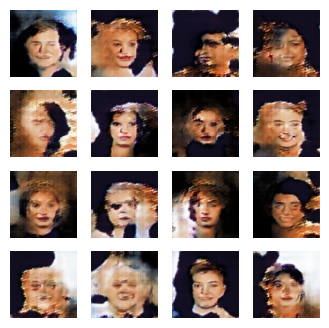

Time for epoch 50 is 48.26 sec


In [ ]:
# Parameters
latent_dim = 100
epochs = 50
batch_size = 64

gan = tuned_GAN(latent_dim=latent_dim, batch_size=batch_size)
gan.train(train_dataset, epochs)

**Comment**: The images appear more realistic than the base model, however there are still some blurs and distortion, therefore more epochs are introduced

## Increasing Epochs

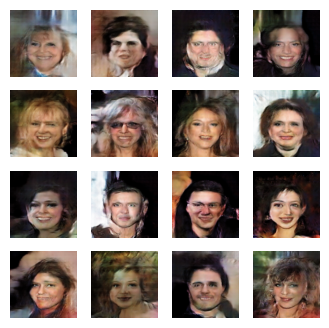

Time for epoch 200 is 71.16 sec


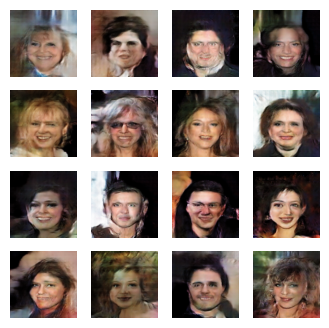

Images saved for epoch 200


In [ ]:
latent_dim = 100
epochs = 200
batch_size = 64
gan = tuned_GAN(latent_dim=latent_dim, batch_size=batch_size)
gan.train(train_dataset, epochs)

In [ ]:
gan.generator.save("generator_tuned.keras")
gan.discriminator.save("discriminator_tuned.keras")

## Tuned Model Evaluation

In [ ]:
# Calculate IS (mean and std)
is_mean, is_stdev = calculate_is(generated_images)
print(f"Inception Score Mean: {is_mean}, Standard Deviation: {is_stdev}")

# Calculate FID
fid_score = calculate_fid(real_images, generated_images)
print(f"FID Score: {fid_score}")

Inception Score Mean: 1.0028456449508667, Standard Deviation: 1.0035501718521118
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
FID Score: 1862.656140232406


## I/O

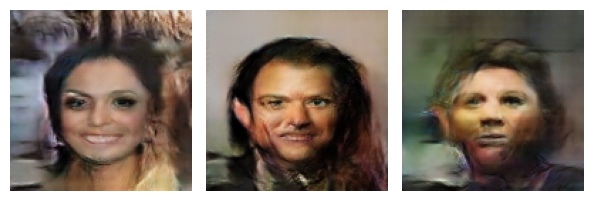

In [ ]:
num_images = 3
latent_dim = 100
noise = tf.random.normal([num_images, latent_dim])

generated_images = gan.generator(noise, training=False) # Generate images
generated_images = (generated_images + 1) / 2.0 # Rescale to [0, 1] for visualization

plt.figure(figsize=(8, 8))
for i in range(num_images):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

## GIF Visualization

In [ ]:
import imageio
import glob
# Specify the output GIF filename
anim_file = 'celeba_gan.gif'

# Create the GIF
with imageio.get_writer(anim_file, mode='I', duration=0.2, loop=0) as writer:
    filenames = sorted(glob.glob('image_at_epoch_*.png'))
    for filename in filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

<ipython-input-47-6d7e78b492d4>:10: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
